In [1]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END

In [3]:
class mulitstate(TypedDict):
    task : str
    results : Annotated[list,add]

In [4]:
def worker_a(state : mulitstate)->dict:
    print(f'[worker_a is running]')
    return {'results':['worker_a Sentimental analysis']}

In [5]:
def worker_b(state : mulitstate)->dict:
    print('worker_b is runing')
    return {'results':['worker_b keyword extraction']}

In [6]:
def worker_c(state : mulitstate)->dict:
    print('worker_c is runing')
    return {'results':['worker_c embeddings completed']}

In [7]:
builder  =  StateGraph(mulitstate)

builder.add_node('worker_a',worker_a)
builder.add_node('worker_b',worker_b)
builder.add_node('worker_c',worker_c)

In [9]:
builder.add_edge(START,"worker_a")
builder.add_edge(START,"worker_b")
builder.add_edge(START,"worker_c")

builder.add_edge("worker_a",END)
builder.add_edge("worker_b",END)
builder.add_edge("worker_c",END)


In [10]:
graph = builder.compile()

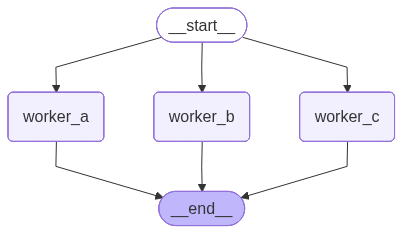

In [11]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [13]:
print("Running parallel graph...")
result = graph.invoke({"task": "analyse document", "results": []})
print()
print("Final results list (merged by the `add` reducer):")
for item in result["results"]:
    print(" -", item)

Running parallel graph...
[worker_a is running]
worker_b is runing
worker_c is runing

Final results list (merged by the `add` reducer):
 - worker_a Sentimental analysis
 - worker_b keyword extraction
 - worker_c embeddings completed


# FAN IN / FAN OUT WORKFLOW

In [33]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END

In [34]:
class mulitstate(TypedDict):
    task : str
    results : Annotated[list,add]
    summary : str

In [35]:
def worker_a(state : mulitstate)->dict:
    print(f'[worker_a is running]')
    return {'results':['worker_a Sentimental analysis']}

In [36]:
def worker_b(state : mulitstate)->dict:
    print('worker_b is runing')
    return {'results':['worker_b keyword extraction']}

In [37]:
def worker_c(state : mulitstate)->dict:
    print('worker_c is runing')
    return {'results':['worker_c embeddings completed']}

In [38]:
def combine(state: mulitstate) -> dict:
    # Fan-IN node: all workers have finished; aggregate their results.
    print("  [combine] aggregating", len(state["results"]), "results...")
    summary = "Document analysis complete.\n"
    for i, r in enumerate(state["results"], 1):
        summary += f"  {i}. {r}\n"
    return {"summary": summary}

In [39]:
builder  =  StateGraph(mulitstate)

builder.add_node('worker_a',worker_a)
builder.add_node('worker_b',worker_b)
builder.add_node('worker_c',worker_c)
builder.add_node('combine',combine)

In [40]:
builder.add_edge(START,"worker_a")
builder.add_edge(START,"worker_b")
builder.add_edge(START,"worker_c")

builder.add_edge("worker_a",'combine')
builder.add_edge("worker_b",'combine')
builder.add_edge("worker_c",'combine')

builder.add_edge('combine',END)

In [41]:

graph_fan = builder.compile()

print("Running fan-out / fan-in graph...\n")
result = graph_fan.invoke({"task": "analyse article", "results": []})
print()
print("Summary:")
print(result["summary"])

Running fan-out / fan-in graph...

[worker_a is running]
worker_b is runing
worker_c is runing
  [combine] aggregating 3 results...

Summary:
Document analysis complete.
  1. worker_a Sentimental analysis
  2. worker_b keyword extraction
  3. worker_c embeddings completed

